In [1]:
!pip install pandas numpy matplotlib tqdm requests

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)


In [9]:
import pandas as pd
import numpy as np
import requests, zipfile, io
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [12]:
def load_aggtrades_day(symbol="BTCUSDT", date="2026-04-28"):
    url = f"https://data.binance.vision/data/spot/daily/aggTrades/{symbol}/{symbol}-aggTrades-{date}.zip"
    print(url)

    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    file = z.namelist()[0]

    df = pd.read_csv(z.open(file))
    df.columns = [
        "agg_id","price","qty","first_id","last_id",
        "timestamp","is_buyer_maker","ignore"
    ]

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="us")
    df["price"] = df["price"].astype(float)
    df["qty"] = df["qty"].astype(float)

    df["is_buy"] = ~df["is_buyer_maker"]

    return df

agg = load_aggtrades_day()
agg.head()

https://data.binance.vision/data/spot/daily/aggTrades/BTCUSDT/BTCUSDT-aggTrades-2026-04-28.zip


,agg_id,price,qty,first_id,last_id,timestamp,is_buyer_maker,ignore,is_buy
0,3946034686,77371.32,0.00064,6256758999,6256758999,2026-04-28 00:00:00.246320,False,True,True
1,3946034687,77371.32,0.00064,6256759000,6256759000,2026-04-28 00:00:00.253074,False,True,True
2,3946034688,77371.32,0.00006,6256759001,6256759001,2026-04-28 00:00:00.283649,False,True,True
3,3946034689,77371.32,0.05640,6256759002,6256759027,2026-04-28 00:00:00.517402,False,True,True
4,3946034690,77371.32,0.02248,6256759028,6256759028,2026-04-28 00:00:00.517484,False,True,True


In [13]:
print("Rows:", len(agg))
print("Time range:", agg["timestamp"].min(), "→", agg["timestamp"].max())
print("Price range:", agg["price"].min(), agg["price"].max())

Rows: 625627
Time range: 2026-04-28 00:00:00.246320 → 2026-04-28 23:59:59.725403
Price range: 75666.6 77478.0


In [14]:
agg["minute"] = agg["timestamp"].dt.floor("1min")

g = agg.groupby("minute")

imb = pd.DataFrame({
    "buy_vol": g.apply(lambda x: x[x["is_buy"]]["qty"].sum()),
    "sell_vol": g.apply(lambda x: x[~x["is_buy"]]["qty"].sum())
}).fillna(0)

imb["imbalance"] = (imb["buy_vol"] - imb["sell_vol"]) / (imb["buy_vol"] + imb["sell_vol"] + 1e-9)
imb.head()

/tmp/ipykernel_398171/632560355.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "buy_vol": g.apply(lambda x: x[x["is_buy"]]["qty"].sum()),
/tmp/ipykernel_398171/632560355.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "sell_vol": g.apply(lambda x: x[~x["is_buy"]]["qty"].sum())


,buy_vol,sell_vol,imbalance
minute,,,
2026-04-28 00:00:00,7.83118,11.64418,-0.195786
2026-04-28 00:01:00,2.78478,5.79403,-0.350777
2026-04-28 00:02:00,1.71522,3.96844,-0.396438
2026-04-28 00:03:00,0.71136,3.31001,-0.646210
2026-04-28 00:04:00,1.34624,7.74986,-0.703996


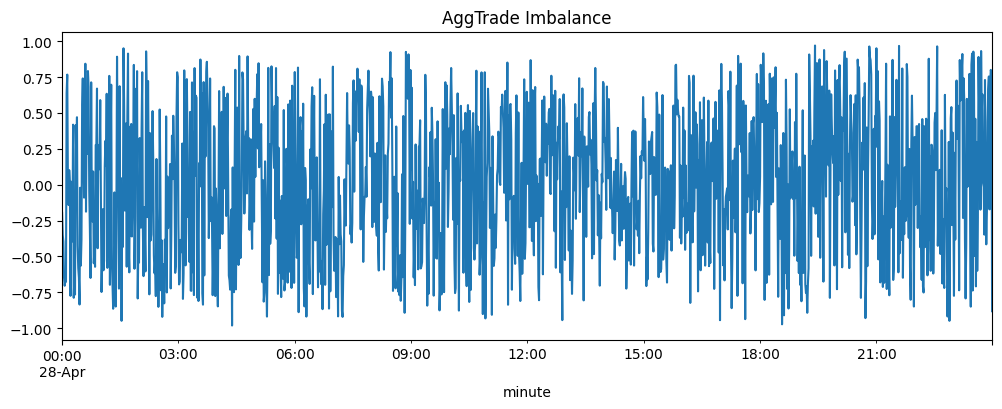

In [15]:
imb["imbalance"].plot(figsize=(12,4), title="AggTrade Imbalance")
plt.show()

In [16]:
imb["imbalance_ema"] = imb["imbalance"].ewm(span=10).mean()
imb["imbalance_std"] = imb["imbalance"].rolling(20).std()
imb["imbalance_z"] = imb["imbalance"] / (imb["imbalance_std"] + 1e-9)

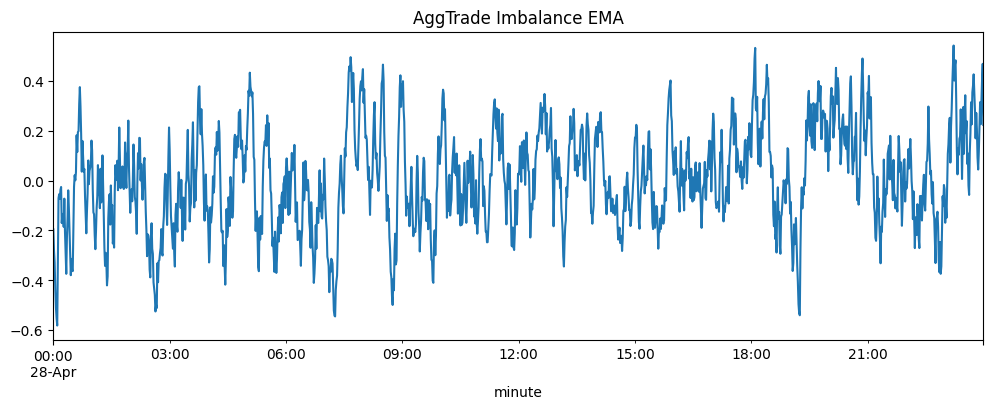

In [18]:
imb["imbalance_ema"].plot(figsize=(12,4), title="AggTrade Imbalance EMA")
plt.show()

In [19]:
def load_futures_metrics(symbol="BTCUSDT", date="2026-04-28"):
    url = f"https://data.binance.vision/data/futures/um/daily/metrics/{symbol}/{symbol}-metrics-{date}.zip"
    print(url)

    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    file = z.namelist()[0]

    df = pd.read_csv(z.open(file))

    df["timestamp"] = pd.to_datetime(df["create_time"], unit="ms", errors="ignore")

    return df

metrics = load_futures_metrics()
metrics.head()

https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2026-04-28.zip


/tmp/ipykernel_398171/669473328.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df["timestamp"] = pd.to_datetime(df["create_time"], unit="ms", errors="ignore")


,create_time,symbol,sum_open_interest,sum_open_interest_value,count_toptrader_long_short_ratio,sum_toptrader_long_short_ratio,count_long_short_ratio,sum_taker_long_short_vol_ratio,timestamp
0,2026-04-28 00:05:00,BTCUSDT,97605.955,7.541514e+09,0.956107,0.786397,0.915514,0.906562,2026-04-28 00:05:00
1,2026-04-28 00:10:00,BTCUSDT,97686.599,7.553576e+09,0.951760,0.787133,0.911472,0.988860,2026-04-28 00:10:00
2,2026-04-28 00:15:00,BTCUSDT,97771.564,7.556393e+09,0.951507,0.789737,0.911644,0.617859,2026-04-28 00:15:00
3,2026-04-28 00:20:00,BTCUSDT,97846.281,7.557431e+09,0.949406,0.791125,0.909047,1.152955,2026-04-28 00:20:00
4,2026-04-28 00:25:00,BTCUSDT,97835.385,7.554273e+09,0.946240,0.790837,0.905941,0.490928,2026-04-28 00:25:00


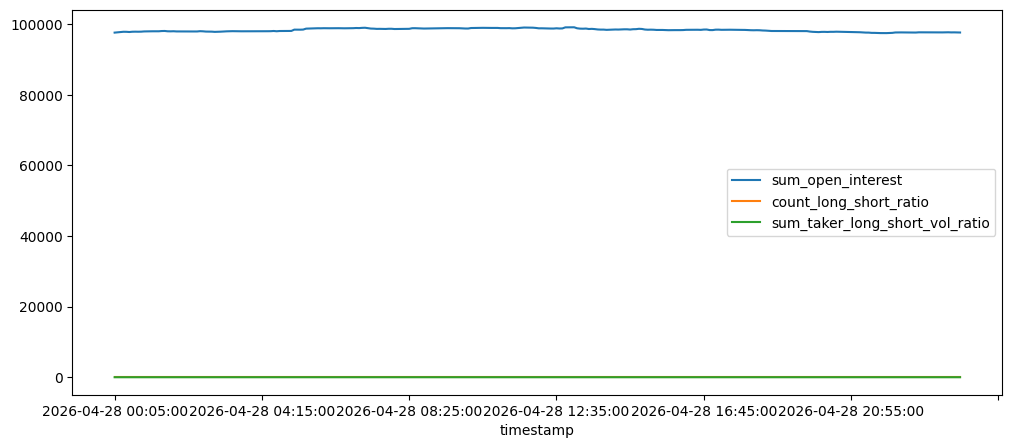

In [20]:
cols = [
    "sum_open_interest",
    "count_long_short_ratio",
    "sum_taker_long_short_vol_ratio"
]

metrics.set_index("timestamp")[cols].plot(figsize=(12,5))
plt.show()

In [21]:
metrics["oi_change"] = metrics["sum_open_interest"].diff()

metrics["oi_z"] = (
    metrics["sum_open_interest"] - metrics["sum_open_interest"].rolling(50).mean()
) / metrics["sum_open_interest"].rolling(50).std()

metrics["taker_ratio_change"] = metrics["sum_taker_long_short_vol_ratio"].diff()

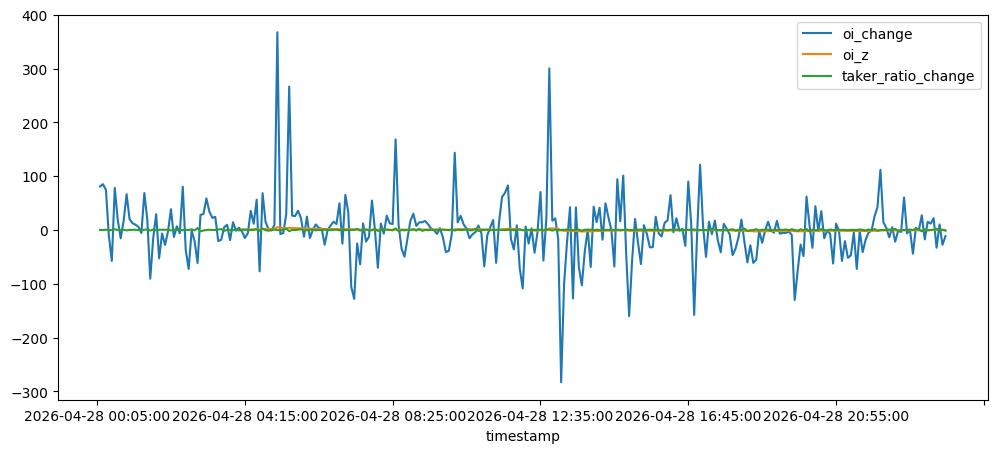

In [22]:
cols = [
    "oi_change",
    "oi_z",
    "taker_ratio_change"
]

metrics.set_index("timestamp")[cols].plot(figsize=(12,5))
plt.show()

In [1]:
!pip install websocket-client

In [3]:
import websocket
import json
import pandas as pd

def on_message(ws, message):
    data = json.loads(message)

    price = float(data["p"])
    qty = float(data["q"])
    is_buyer_maker = data["m"]

    is_buy = not is_buyer_maker

    print({
        "price": price,
        "qty": qty,
        "is_buy": is_buy,
        "timestamp": data["T"]
    })

def on_error(ws, error):
    print("Error:", error)

def on_close(ws, close_status_code, close_msg):
    print("Closed")

def on_open(ws):
    print("Connected")

ws = websocket.WebSocketApp(
    "wss://stream.binance.com:9443/ws/btcusdt@aggTrade",
    on_message=on_message,
    on_error=on_error,
    on_close=on_close
)

ws.on_open = on_open
ws.run_forever()

Connected
{'price': 75681.82, 'qty': 0.00013, 'is_buy': False, 'timestamp': 1777493449763}
{'price': 75681.82, 'qty': 0.00147, 'is_buy': False, 'timestamp': 1777493449834}
{'price': 75681.82, 'qty': 0.00397, 'is_buy': False, 'timestamp': 1777493450011}
{'price': 75681.82, 'qty': 0.00099, 'is_buy': False, 'timestamp': 1777493450748}
{'price': 75681.83, 'qty': 0.00263, 'is_buy': True, 'timestamp': 1777493451277}
{'price': 75681.82, 'qty': 0.11714, 'is_buy': False, 'timestamp': 1777493451517}
{'price': 75681.83, 'qty': 0.06459, 'is_buy': True, 'timestamp': 1777493451588}
{'price': 75681.83, 'qty': 0.07008, 'is_buy': True, 'timestamp': 1777493453162}
{'price': 75681.82, 'qty': 0.51453, 'is_buy': False, 'timestamp': 1777493454116}
{'price': 75681.82, 'qty': 0.00135, 'is_buy': False, 'timestamp': 1777493454403}
{'price': 75681.82, 'qty': 0.00135, 'is_buy': False, 'timestamp': 1777493454410}
{'price': 75681.82, 'qty': 0.00118, 'is_buy': False, 'timestamp': 1777493454517}
{'price': 75681.81, '

True

In [7]:
def on_message(ws, message):
    data = json.loads(message)

    print({
        "mark_price": float(data["p"]),
        "funding_rate": float(data["r"]),
        "timestamp": data["E"]
    })

ws = websocket.WebSocketApp(
    "wss://fstream.binance.com/market/ws/btcusdt@markPrice",
    on_message=on_message
)

ws.run_forever()

{'mark_price': 75615.36136232, 'funding_rate': 2.2e-07, 'timestamp': 1777494081001}
{'mark_price': 75613.24230435, 'funding_rate': 2.2e-07, 'timestamp': 1777494084002}
{'mark_price': 75613.24447826, 'funding_rate': 2.2e-07, 'timestamp': 1777494087000}
{'mark_price': 75612.84134783, 'funding_rate': 2.2e-07, 'timestamp': 1777494090000}
{'mark_price': 75626.3, 'funding_rate': 2.2e-07, 'timestamp': 1777494093000}
{'mark_price': 75626.4, 'funding_rate': 2.2e-07, 'timestamp': 1777494096001}
{'mark_price': 75625.35663043, 'funding_rate': 2.2e-07, 'timestamp': 1777494099000}
{'mark_price': 75623.37698551, 'funding_rate': 2.2e-07, 'timestamp': 1777494102000}
{'mark_price': 75623.38785507, 'funding_rate': 2.2e-07, 'timestamp': 1777494105004}
{'mark_price': 75613.56091454, 'funding_rate': 2.2e-07, 'timestamp': 1777494108000}
{'mark_price': 75608.88113193, 'funding_rate': 2.2e-07, 'timestamp': 1777494111000}
{'mark_price': 75607.54426087, 'funding_rate': 2.2e-07, 'timestamp': 1777494114003}
{'mark

True

In [8]:
import requests, time

def fetch_oi():
    url = "https://fapi.binance.com/fapi/v1/openInterest"
    params = {"symbol": "BTCUSDT"}
    return float(requests.get(url, params=params).json()["openInterest"])

for _ in range(5):
    print("OI:", fetch_oi())
    time.sleep(2)

OI: 95023.115
OI: 95023.115
OI: 95023.115
OI: 95022.422
OI: 95022.422


In [23]:
def fetch_long_short():
    url = "https://fapi.binance.com/futures/data/globalLongShortAccountRatio"
    params = {
        "symbol": "BTCUSDT",
        "period": "5m",
        "limit": 1
    }

    data = requests.get(url, params=params).json()[0]

    print({
        "long_short_ratio": float(data["longShortRatio"]),
        "long": float(data["longAccount"]),
        "short": float(data["shortAccount"])
    })

fetch_long_short()

{'long_short_ratio': 1.0425, 'long': 0.5104, 'short': 0.4896}


In [24]:
def fetch_taker_ratio():
    url = "https://fapi.binance.com/futures/data/takerlongshortRatio"
    params = {
        "symbol": "BTCUSDT",
        "period": "5m",
        "limit": 1
    }

    data = requests.get(url, params=params).json()[0]

    print({
        "buy_sell_ratio": float(data["buySellRatio"])
    })

fetch_taker_ratio()

{'buy_sell_ratio': 1.6024}
